In [1]:
import numpy as np
import pandas as pd
import torch

from data_generators.garch import garch_data_generator, garch_option_price_mc, garch_chart
from data_generators.heston import heston_data_generator, heston_option_price_mc, heston_chart
from dataset.dataset import AADeepHedgingDataset, loader
from ambiguity_measures.KMeans_algo import *
from utils.options import *
from utils.PL import *
from models.neural_network import HedgingNN
from training.train_loop_nn import main
from risk_measures.test_metrics import test_result_metrics, compute_PL_array, evaluate_real_data_performance
from utils.charts import plot_pnl_distributions, plot_deltas, plot_models_deltas_comparison

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Generate Heston Training Paths

In [2]:
S0 = 1.0
K = 1.0
T = 30 / 252
N = 30
seed = 1

n_simulations = 100000

heston_params = {
    "S0": S0,
    "v0": 0.04,
    "T": T,
    "N": N,
    "r": 0.0,
    "mu": 0.0,
    "kappa": 2.0, 
    "theta": 0.04,
    "sigma_v": 3.5,
    "rho": -0.7,
    "risk_neutrality": True,
    "random": True,
}

garch_params = {
    "S0": S0,
    "T": T,
    "N": N,
    "mu": 0.0,
    "alpha": 0.08,
    "beta": 0.90,
    "long_run_variance": 0.04,
    "initial_variance": 0.04,
    "random": True,
}

data_S, data_v = heston_data_generator(**heston_params, n_simulations=n_simulations, seed=seed)
option_price, option_std_error = heston_option_price_mc(data_S=data_S,
                                                        K=K,
                                                        mu=heston_params["mu"],
                                                        r=heston_params["r"],
                                                        T=T,
                                                        risk_neutrality=heston_params["risk_neutrality"])

# To switch back to GARCH-only training, uncomment these lines:
# data_S, data_var = garch_data_generator(**garch_params, n_simulations=n_simulations, seed=seed)
# option_price, option_std_error = garch_option_price_mc(data_S=data_S, K=K, mu=0.0, T=T)


Monte Carlo option price 0.0415 +- 0.0003 (95% CI)


### KMeans Clustering

In [3]:
n_clusters = 4
feature_matrix = compute_feature_matrix(data_S)
labels, kmeans_model = kmeans_clustering(feature_matrix, n_clusters=n_clusters)
probs = calculate_cluster_probabilities(labels)

for label, data in probs.items():
    print(f"Label: {label}, Probability: {data['probability']}")

Label: 0, Probability: 0.50189
Label: 1, Probability: 0.22524
Label: 2, Probability: 0.06628
Label: 3, Probability: 0.20659


In [4]:
dataset_kmeans = AADeepHedgingDataset(data_S, labels)

In [5]:
batch_size = 1000

train_data, val_data, test_data = loader(dataset_kmeans,
                                         batch_size=batch_size,
                                         set_proportions=[0.6, 0.2, 0.2],
                                         shuffle=False)

### Train AADH and SDH on Heston

In [6]:
epochs = 200
cost_rate = 0.002
learning_rate = 1e-4
alpha = 250
lam = 1 / 100
schedule = [(0, 1), (100, 10), (150, 100)]

In [7]:
torch.manual_seed(seed)
AADH_model = HedgingNN().to(device)

AADH_model = main(model=AADH_model,
                  train_loader=train_data,
                  val_loader=val_data,
                  option_type_fn=eur_call_payoff,
                  strike=K,
                  cost_rate=cost_rate,
                  lam=lam,
                  alpha=alpha,
                  epochs=epochs,
                  learning_rate=learning_rate,
                  AADH=True,
                  adaptive_learning=True,
                  schedule=schedule,
                  device=device)

Epoch 1/200 - Learning Rate: 0.0001
Train Loss: 0.0026305835 | Val Loss: 0.0024825810

-------------------------------------------------------
Epoch 2/200 - Learning Rate: 0.0001
Train Loss: 0.0012781012 | Val Loss: 0.0006622519

-------------------------------------------------------
Epoch 3/200 - Learning Rate: 0.0001
Train Loss: 0.0006071610 | Val Loss: 0.0005540923

-------------------------------------------------------
Epoch 4/200 - Learning Rate: 0.0001
Train Loss: 0.0004702173 | Val Loss: 0.0003821706

-------------------------------------------------------
Epoch 5/200 - Learning Rate: 0.0001
Train Loss: 0.0003235711 | Val Loss: 0.0003137104

-------------------------------------------------------
Epoch 6/200 - Learning Rate: 0.0001
Train Loss: 0.0002971079 | Val Loss: 0.0002977395

-------------------------------------------------------
Epoch 7/200 - Learning Rate: 0.0001
Train Loss: 0.0002876892 | Val Loss: 0.0002919700

-------------------------------------------------------

In [8]:
torch.manual_seed(seed)
SDH_model = HedgingNN().to(device)

SDH_model = main(model=SDH_model,
                 train_loader=train_data,
                 val_loader=val_data,
                 option_type_fn=eur_call_payoff,
                 strike=K,
                 cost_rate=cost_rate,
                 lam=lam,
                 alpha=alpha,
                 epochs=epochs,
                 learning_rate=learning_rate,
                 AADH=False,
                 adaptive_learning=True,
                 schedule=schedule,
                 device=device)

Epoch 1/200 - Learning Rate: 0.0001
Train Loss: 0.0029139169 | Val Loss: 0.0027134402

-------------------------------------------------------
Epoch 2/200 - Learning Rate: 0.0001
Train Loss: 0.0015232044 | Val Loss: 0.0010008722

-------------------------------------------------------
Epoch 3/200 - Learning Rate: 0.0001
Train Loss: 0.0009493975 | Val Loss: 0.0008913434

-------------------------------------------------------
Epoch 4/200 - Learning Rate: 0.0001
Train Loss: 0.0008088036 | Val Loss: 0.0007178286

-------------------------------------------------------
Epoch 5/200 - Learning Rate: 0.0001
Train Loss: 0.0006085379 | Val Loss: 0.0005415544

-------------------------------------------------------
Epoch 6/200 - Learning Rate: 0.0001
Train Loss: 0.0005234791 | Val Loss: 0.0005229019

-------------------------------------------------------
Epoch 7/200 - Learning Rate: 0.0001
Train Loss: 0.0005093070 | Val Loss: 0.0005087192

-------------------------------------------------------

In [9]:
print(test_result_metrics(SDH_model, test_data, strike=K, cost_rate=cost_rate, lam=lam))
print(test_result_metrics(AADH_model, test_data, strike=K, cost_rate=cost_rate, lam=lam))

(0.00045031681656837463, 0.000444208417320624, 0.003131334437057376)
(0.0007101622177287936, 0.0006999674369581044, 0.002578719751909375)


SDH P&L Summary: Mean = -0.00293949, Std = 0.02107917
AADH P&L Summary: Mean = -0.00241203, Std = 0.02645503


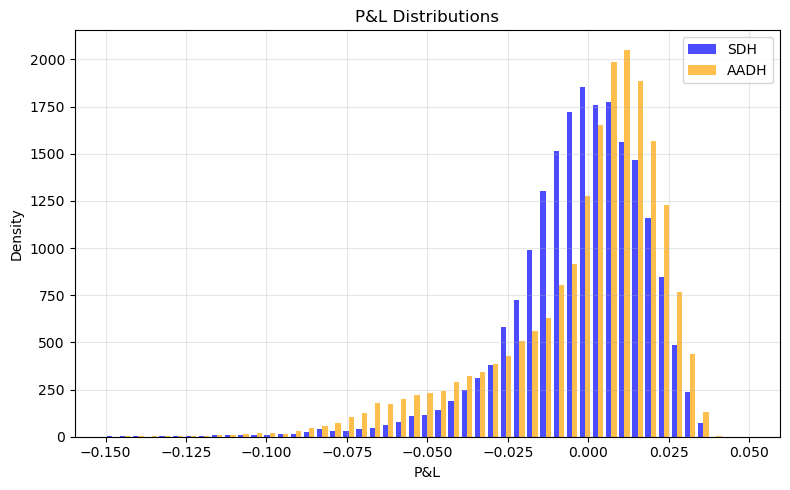

In [10]:
PL_array_SDH = compute_PL_array(SDH_model, test_data, option_type_fn=eur_call_payoff, 
                                strike=K, cost_rate=cost_rate, p0=option_price, device=device)
PL_array_AADH = compute_PL_array(AADH_model, test_data, option_type_fn=eur_call_payoff, 
                                 strike=K, cost_rate=cost_rate, p0=option_price, device=device)

plot_pnl_distributions(PL_array_SDH, PL_array_AADH, bins_range=(-0.15,0.05), num_bins=50, 
                       labels=("SDH", "AADH"),
                       title="P&L Distributions", xlabel="P&L", ylabel="Density")

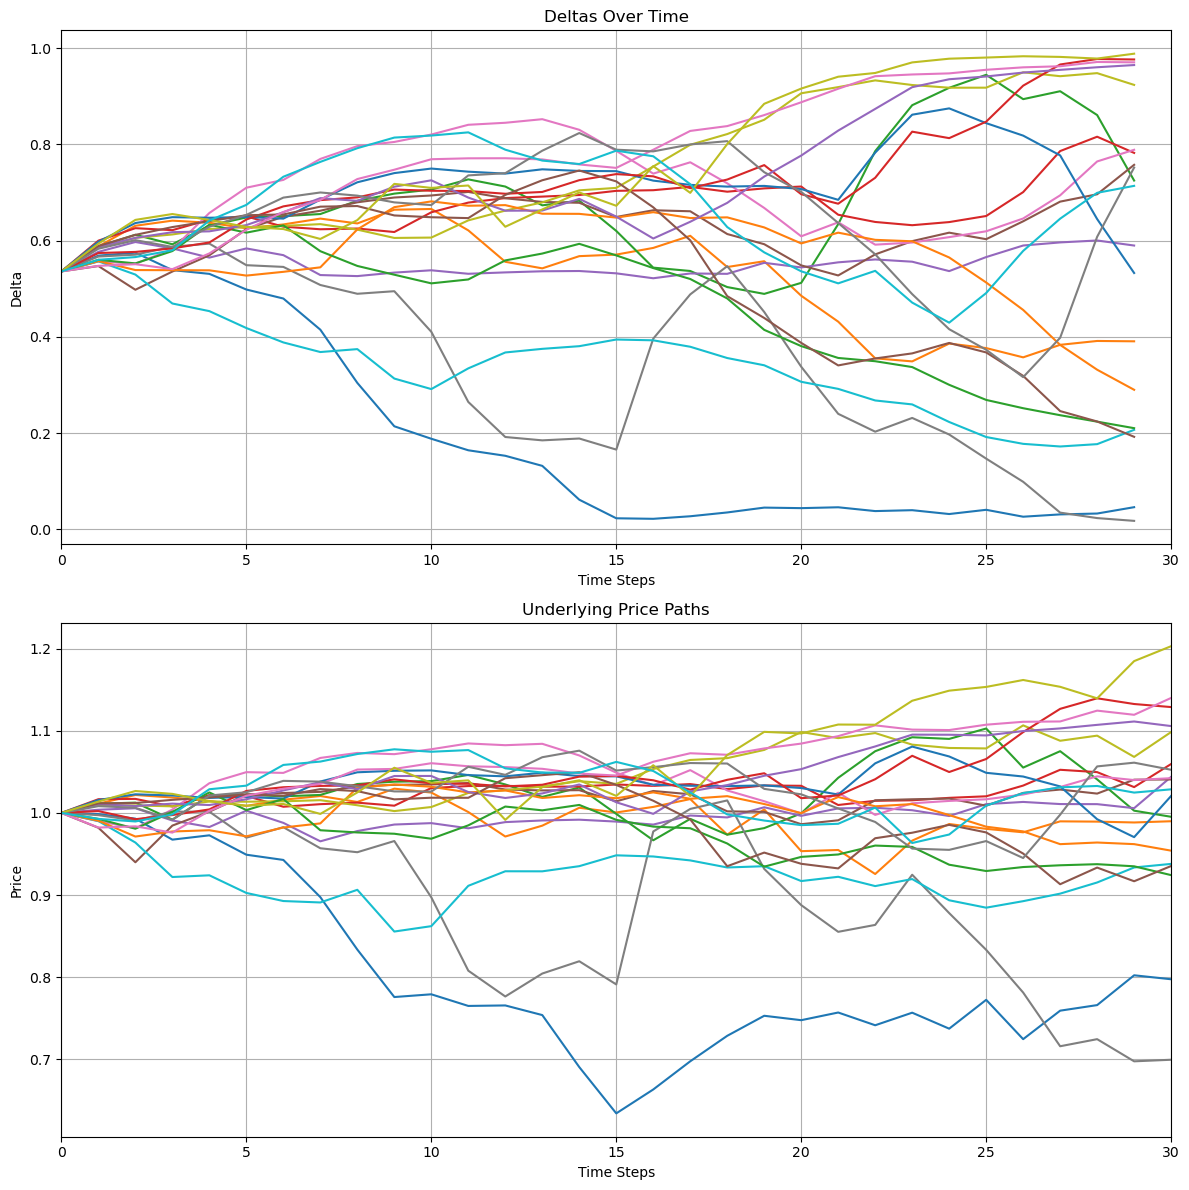

In [11]:
plot_deltas(test_data, AADH_model, n_paths=20, device=device)
# plot_deltas(test_data, SDH_model, n_paths=20, device=device)

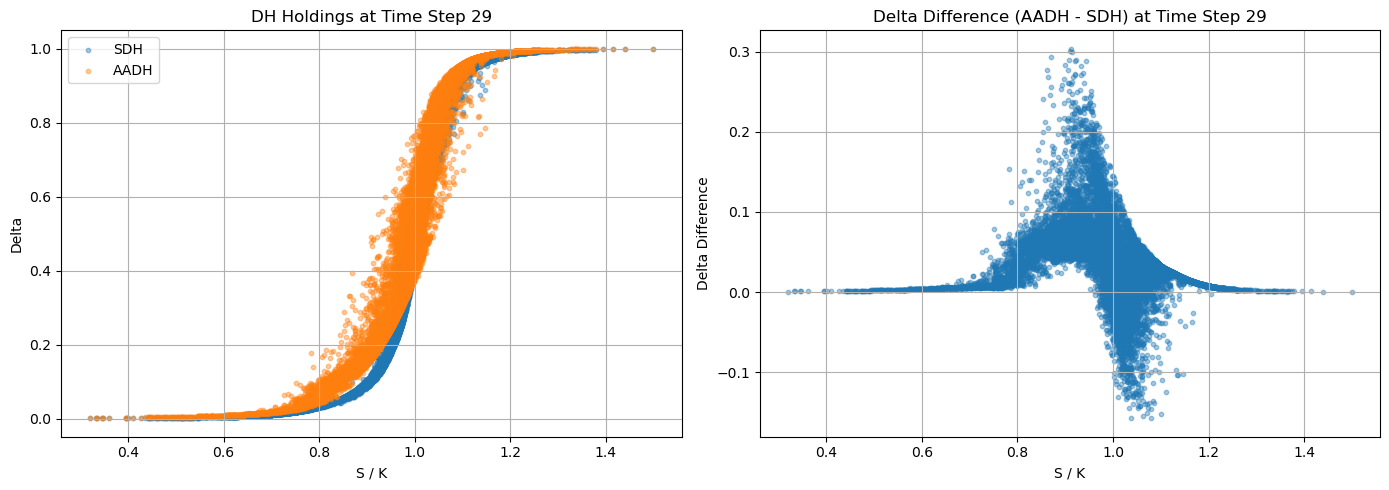

In [12]:
plot_models_deltas_comparison(SDH_model, AADH_model, test_data, time_step=N-1, K=K, device=device)

### Test on Heston/GARCH Mixtures

In [18]:
# heston_params and garch_params are defined above.
# The test set below changes only the mixture proportions.

test_heston_weights = [0.0, 0.03, 0.04, 0.05, 0.1, 0.15, 0.25, 0.50, 1.0]
n_test_simulations = 100000

In [19]:
results = []

for i, heston_weight in enumerate(test_heston_weights):
    n_heston = int(round(heston_weight * n_test_simulations))
    n_garch = n_test_simulations - n_heston
    test_parts = []

    if n_heston > 0:
        data_S_heston, _ = heston_data_generator(
            **heston_params,
            n_simulations=n_heston,
            seed=seed + 1000 * i
        )
        test_parts.append(data_S_heston)

    if n_garch > 0:
        data_S_garch, _ = garch_data_generator(
            **garch_params,
            n_simulations=n_garch,
            seed=seed + 1000 * i + 1
        )
        test_parts.append(data_S_garch)

    test_data_S = pd.concat(test_parts, axis=1, ignore_index=True)

    permutation = np.random.default_rng(
        seed + 1000 * i + 2
    ).permutation(test_data_S.shape[1])

    test_data_S = test_data_S.iloc[:, permutation]
    test_data_S.columns = range(test_data_S.shape[1])

    test_feature_matrix = compute_feature_matrix(test_data_S)
    test_labels = kmeans_model.predict(test_feature_matrix)

    test_dataset = AADeepHedgingDataset(test_data_S, test_labels)

    mixture_test_loader, _, _ = loader(
        test_dataset,
        batch_size=batch_size,
        set_proportions=[1.0, 0.0, 0.0],
        shuffle=False
    )

    print(f"Test mixture: {heston_weight:.0%} Heston, "
          f"{1 - heston_weight:.0%} GARCH")

    print("SDH")

    sdh_metrics = test_result_metrics(
        SDH_model,
        mixture_test_loader,
        option_type_fn=eur_call_payoff,
        strike=K,
        cost_rate=cost_rate,
        lam=lam,
        device=device
    )

    print(sdh_metrics)

    # Compute SDH P&L array and mean P&L
    sdh_pnl = compute_PL_array(
        SDH_model,
        mixture_test_loader,
        option_type_fn=eur_call_payoff,
        strike=K,
        cost_rate=cost_rate,
        p0=0.0,
        device=device
    )

    sdh_mean_pnl = np.mean(sdh_pnl)

    print(f"SDH mean P&L: {sdh_mean_pnl:.8f}")

    
    print("AADH")

    aadh_metrics = test_result_metrics(
        AADH_model,
        mixture_test_loader,
        option_type_fn=eur_call_payoff,
        strike=K,
        cost_rate=cost_rate,
        lam=lam,
        device=device
    )
    print(aadh_metrics)

    # Compute AADH P&L array and mean P&L
    aadh_pnl = compute_PL_array(
        AADH_model,
        mixture_test_loader,
        option_type_fn=eur_call_payoff,
        strike=K,
        cost_rate=cost_rate,
        p0=0.0,
        device=device
    )

    aadh_mean_pnl = np.mean(aadh_pnl)
    print(f"AADH mean P&L: {aadh_mean_pnl:.8f}")

    diff_metrics = tuple(
        sdh_value - aadh_value
        for sdh_value, aadh_value in zip(sdh_metrics, aadh_metrics)
    )

    print("SDH - AADH (overall risk, variance, transaction costs)")
    print(diff_metrics)

    # Optional: difference in mean P&L
    mean_pnl_diff = sdh_mean_pnl - aadh_mean_pnl

    print(f"SDH - AADH mean P&L: {mean_pnl_diff:.8f}")
    print("-" * 55)

    results.append({
        "test_heston_weight": heston_weight,
        "test_garch_weight": 1 - heston_weight,

        "SDH_overall_risk": sdh_metrics[0],
        "SDH_variance": sdh_metrics[1],
        "SDH_transaction_costs": sdh_metrics[2],
        "SDH_mean_PnL": sdh_mean_pnl,

        "AADH_overall_risk": aadh_metrics[0],
        "AADH_variance": aadh_metrics[1],
        "AADH_transaction_costs": aadh_metrics[2],
        "AADH_mean_PnL": aadh_mean_pnl,

        "risk_diff_SDH_minus_AADH": diff_metrics[0],
        "variance_diff_SDH_minus_AADH": diff_metrics[1],
        "cost_diff_SDH_minus_AADH": diff_metrics[2],
        "mean_PnL_diff_SDH_minus_AADH": mean_pnl_diff,
    })

Test mixture: 0% Heston, 100% GARCH
SDH
(0.00015734689077362418, 0.00013418258458841592, 0.0027398858219385147)
SDH mean P&L: -0.02964219
AADH
(0.0001854642032412812, 0.00016376936400774866, 0.0023171145003288984)
AADH mean P&L: -0.02917740
SDH - AADH (overall risk, variance, transaction costs)
(-2.811731246765703e-05, -2.9586779419332743e-05, 0.0004227713216096163)
SDH - AADH mean P&L: -0.00046479
-------------------------------------------------------
Test mixture: 3% Heston, 97% GARCH
SDH
(0.00017101610137615353, 0.00014865247067064047, 0.0027527399361133575)
SDH mean P&L: -0.03007984
AADH
(0.00020725536160171032, 0.00018609857943374664, 0.0023248421493917704)
AADH mean P&L: -0.02964308
SDH - AADH (overall risk, variance, transaction costs)
(-3.623926022555679e-05, -3.744610876310617e-05, 0.0004278977867215872)
SDH - AADH mean P&L: -0.00043676
-------------------------------------------------------
Test mixture: 4% Heston, 96% GARCH
SDH
(0.00017677751020528376, 0.0001547389401821419

In [20]:
results_df = pd.DataFrame(results)
results_df

,test_heston_weight,test_garch_weight,SDH_overall_risk,SDH_variance,SDH_transaction_costs,SDH_mean_PnL,AADH_overall_risk,AADH_variance,AADH_transaction_costs,AADH_mean_PnL,risk_diff_SDH_minus_AADH,variance_diff_SDH_minus_AADH,cost_diff_SDH_minus_AADH,mean_PnL_diff_SDH_minus_AADH
0,0.00,1.00,0.000157,0.000134,0.002740,-0.029642,0.000185,0.000164,0.002317,-0.029177,-0.000028,-0.000030,0.000423,-0.000465
1,0.03,0.97,0.000171,0.000149,0.002753,-0.030080,0.000207,0.000186,0.002325,-0.029643,-0.000036,-0.000037,0.000428,-0.000437
2,0.04,0.96,0.000177,0.000155,0.002756,-0.030164,0.000218,0.000197,0.002327,-0.029768,-0.000041,-0.000042,0.000428,-0.000396
3,0.05,0.95,0.000180,0.000158,0.002762,-0.030369,0.000219,0.000198,0.002331,-0.029919,-0.000039,-0.000040,0.000431,-0.000450
4,0.10,0.90,0.000204,0.000184,0.002782,-0.031110,0.000256,0.000236,0.002345,-0.030710,-0.000052,-0.000052,0.000437,-0.000400
5,0.15,0.85,0.000230,0.000211,0.002799,-0.031831,0.000296,0.000277,0.002356,-0.031373,-0.000066,-0.000066,0.000443,-0.000457
6,0.25,0.75,0.000270,0.000253,0.002835,-0.033345,0.000359,0.000342,0.002381,-0.032927,-0.000089,-0.000089,0.000454,-0.000419
7,0.50,0.50,0.000359,0.000348,0.002938,-0.037079,0.000504,0.000490,0.002450,-0.036650,-0.000145,-0.000142,0.000488,-0.000429
8,1.00,0.00,0.000450,0.000444,0.003136,-0.044530,0.000703,0.000692,0.002582,-0.043954,-0.000253,-0.000249,0.000553,-0.000577


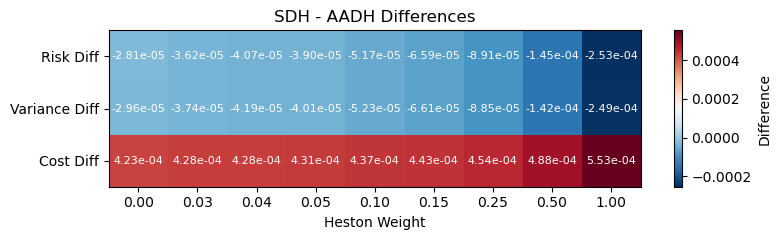

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

heatmap_data = results_df[
    [
        "risk_diff_SDH_minus_AADH",
        "variance_diff_SDH_minus_AADH",
        "cost_diff_SDH_minus_AADH",
    ]
].T

heatmap_data.columns = [
    f"{w:.2f}" for w in results_df["test_heston_weight"]
]

# Etichette delle righe
heatmap_data.index = [
    "Risk Diff",
    "Variance Diff",
    "Cost Diff"
]

fig, ax = plt.subplots(figsize=(8, 2.5))

im = ax.imshow(
    heatmap_data,
    cmap="RdBu_r",   
    aspect="auto"
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_xlabel("Heston Weight")
ax.set_title("SDH - AADH Differences")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_data.iloc[i, j]:.2e}",
            ha="center",
            va="center",
            fontsize=8,
            color="white"
        )

plt.colorbar(im, ax=ax, label="Difference")

plt.tight_layout()
plt.show()

### Test on Empirical Real Data


In [22]:
from pathlib import Path

real_data_tests = [
    (
        "SP500 10y - Correct Window",
        "dataset/real_data/SP500_10y_samples.csv",
    ),
    (
        "SP500 10y - Wrong Window",
        "dataset/real_data/SP500_10y_samples_2.csv",
    ),
    (
        "SP500 10y - Open",
        "dataset/real_data/SP500_10y_samples_new_open.csv",
    ),
    (
        "ES 50 original period - Correct Window",
        "dataset/real_data/ES_50_samples_new.csv",
    ),
    (
        "ES 50 original period - Wrong Window",
        "dataset/real_data/ES_50_samples_2.csv",
    ),
    (
        "ES 50 original period - Open",
        "dataset/real_data/ES_50_samples_new_open.csv",
    ),
    (
        "FTSE 100 - Correct Window",
        "dataset/real_data/FTSE_100_samples_new.csv",
    ),
    (
        "FTSE 100 - Wrong Window",
        "dataset/real_data/FTSE_100_samples.csv",
    ),
    (
        "FTSE 100 - Open",
        "dataset/real_data/FTSE_100_samples_new_open.csv",
    ),
    (
        "Nikkei 225 - Correct Window",
        "dataset/real_data/Nikkei_225_samples_new.csv",
    ),
    (
        "Nikkei 225 - Wrong Window",
        "dataset/real_data/Nikkei_225_samples.csv",
    ),
    (
        "Nikkei 225 - Open",
        "dataset/real_data/Nikkei_225_samples_new_open.csv",
    ),
    (
        "Nasdaq 100 - Correct Window",
        "dataset/real_data/Nasdaq_100_samples_new.csv",
    ),
    (
        "Nasdaq 100 - Wrong Window",
        "dataset/real_data/Nasdaq_100_samples.csv",
    ),
    (
        "Nasdaq 100 - Open",
        "dataset/real_data/Nasdaq_100_samples_new_open.csv",
    )
    


# print(create_real_data_dataset("SP500_10y.xlsx", "SP500_10y_samples_new_open.csv", 30))
# print(create_real_data_dataset("ES_50_Covid.xlsx", "ES_50_Covid_samples_new_open.csv", 30))
# print(create_real_data_dataset("FTSE_100.xlsx", "FTSE_100_samples_new_open.csv", 30))
# print(create_real_data_dataset("Nasdaq_100.xlsx", "Nasdaq_100_samples_new_open.csv", 30))
# print(create_real_data_dataset("Nikkei_225.xlsx", "Nikkei_225_samples_new_open.csv", 30))


    # Optional corrected no-Covid windows from Main_test_5.
    # (
    #     "SP500 no Covid rebound - Correct Window",
    #     "dataset/real_data/SP_500_samples_no_tails_new.csv",
    # ),
    # (
    #     "SP500 no Covid crisis - Correct Window",
    #     "dataset/real_data/SP_500_samples_no_tails_2_new.csv",
    # ),
]

real_results = []

for dataset_name, data_path in real_data_tests:
    if not Path(data_path).exists():
        print(f"Skipping missing file: {data_path}")
        continue

    print(dataset_name)
    print("SDH")
    sdh_metrics = evaluate_real_data_performance(
        data_path,
        kmeans_model=kmeans_model,
        evaluation_model=SDH_model,
        strike=K,
        cost_rate=cost_rate,
        lam=lam,
        batch_size=batch_size,
        device=device,
    )
    print(sdh_metrics)

    print("AADH")
    aadh_metrics = evaluate_real_data_performance(
        data_path,
        kmeans_model=kmeans_model,
        evaluation_model=AADH_model,
        strike=K,
        cost_rate=cost_rate,
        lam=lam,
        batch_size=batch_size,
        device=device,
    )
    print(aadh_metrics)

    diff_metrics = tuple(
        sdh_value - aadh_value
        for sdh_value, aadh_value in zip(sdh_metrics, aadh_metrics)
    )
    print("SDH - AADH (overall risk, variance, transaction costs)")
    print(diff_metrics)
    print("-" * 55)

    real_results.append({
        "dataset": dataset_name,
        "path": data_path,
        "SDH_overall_risk": sdh_metrics[0],
        "SDH_variance": sdh_metrics[1],
        "SDH_transaction_costs": sdh_metrics[2],
        "AADH_overall_risk": aadh_metrics[0],
        "AADH_variance": aadh_metrics[1],
        "AADH_transaction_costs": aadh_metrics[2],
        "risk_diff_SDH_minus_AADH": diff_metrics[0],
        "variance_diff_SDH_minus_AADH": diff_metrics[1],
        "cost_diff_SDH_minus_AADH": diff_metrics[2],
    })

real_results_df = pd.DataFrame(real_results)
real_results_df


SP500 10y - Correct Window
SDH
(0.00017631186346989125, 0.00016217930533457547, 0.0023148520849645138)
AADH
(0.00020748314273077995, 0.00019283244910184294, 0.00204569473862648)
SDH - AADH (overall risk, variance, transaction costs)
(-3.1171279260888696e-05, -3.0653143767267466e-05, 0.0002691573463380337)
-------------------------------------------------------
SP500 10y - Wrong Window
SDH
(0.00029373072902671993, 0.00029034054023213685, 0.002238640794530511)
AADH
(0.00019912149582523853, 0.00018550443928688765, 0.0020415897015482187)
SDH - AADH (overall risk, variance, transaction costs)
(9.46092332014814e-05, 0.0001048361009452492, 0.00019705109298229218)
-------------------------------------------------------
SP500 10y - Open
SDH
(0.00014085213479120284, 0.00012450217036530375, 0.002236490836367011)
AADH
(0.0001820350153138861, 0.00016665022121742368, 0.002018593018874526)
SDH - AADH (overall risk, variance, transaction costs)
(-4.118288052268326e-05, -4.214805085211992e-05, 0.000217

,dataset,path,SDH_overall_risk,SDH_variance,SDH_transaction_costs,AADH_overall_risk,AADH_variance,AADH_transaction_costs,risk_diff_SDH_minus_AADH,variance_diff_SDH_minus_AADH,cost_diff_SDH_minus_AADH
0,SP500 10y - Correct Window,dataset/real_data/SP500_10y_samples.csv,0.000176,0.000162,0.002315,0.000207,0.000193,0.002046,-0.000031,-0.000031,0.000269
1,SP500 10y - Wrong Window,dataset/real_data/SP500_10y_samples_2.csv,0.000294,0.000290,0.002239,0.000199,0.000186,0.002042,0.000095,0.000105,0.000197
2,SP500 10y - Open,dataset/real_data/SP500_10y_samples_new_open.csv,0.000141,0.000125,0.002236,0.000182,0.000167,0.002019,-0.000041,-0.000042,0.000218
3,ES 50 original period - Correct Window,dataset/real_data/ES_50_samples_new.csv,0.000177,0.000160,0.002471,0.000227,0.000210,0.002138,-0.000050,-0.000051,0.000333
4,ES 50 original period - Wrong Window,dataset/real_data/ES_50_samples_2.csv,0.000259,0.000248,0.002443,0.000228,0.000212,0.002153,0.000031,0.000036,0.000291
5,ES 50 original period - Open,dataset/real_data/ES_50_samples_new_open.csv,0.000161,0.000143,0.002362,0.000215,0.000198,0.002101,-0.000054,-0.000055,0.000260
6,FTSE 100 - Correct Window,dataset/real_data/FTSE_100_samples_new.csv,0.000140,0.000125,0.002165,0.000169,0.000153,0.001965,-0.000029,-0.000029,0.000200
7,FTSE 100 - Wrong Window,dataset/real_data/FTSE_100_samples.csv,0.000188,0.000177,0.002133,0.000165,0.000150,0.001977,0.000023,0.000027,0.000156
8,FTSE 100 - Open,dataset/real_data/FTSE_100_samples_new_open.csv,0.000140,0.000125,0.002164,0.000169,0.000154,0.001965,-0.000029,-0.000029,0.000199
9,Nikkei 225 - Correct Window,dataset/real_data/Nikkei_225_samples_new.csv,0.000178,0.000157,0.002600,0.000196,0.000177,0.002223,-0.000017,-0.000020,0.000377
